<a href="https://colab.research.google.com/github/RizkyFirdiansyah/PCVK_Ganjil2026/blob/main/Week06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

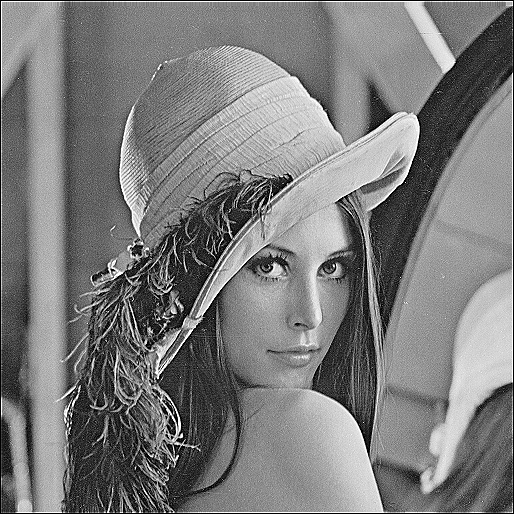

In [ ]:
def convolution2d(image, kernel, stride, padding):
  if padding > 0:
    padded_img = np.pad(image, ((padding, padding), (padding, padding)), 'constant', constant_values=0)
  else:
    padded_img = image

  kernel_height, kernel_width = kernel.shape
  image_height, image_width = padded_img.shape

  output_height = math.floor((image_height - kernel_height) / stride) + 1
  output_width = math.floor((image_width - kernel_width) / stride) + 1

  output = np.zeros((output_height, output_width))

  for y in range(output_height):
    for x in range(output_width):
      sub_matrix = padded_img[y*stride:y*stride+kernel_height, x*stride:x*stride+kernel_width]
      output[y, x] = np.sum(sub_matrix * kernel)

  return np.clip(output, 0, 255).astype(np.uint8)

img = cv.imread('/content/drive/MyDrive/PCVK2026/Lenna.png')
gray_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
kernel_sharpen = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
sharpened_img = convolution2d(gray_img, kernel_sharpen, 1, 2)
cv2_imshow(sharpened_img)

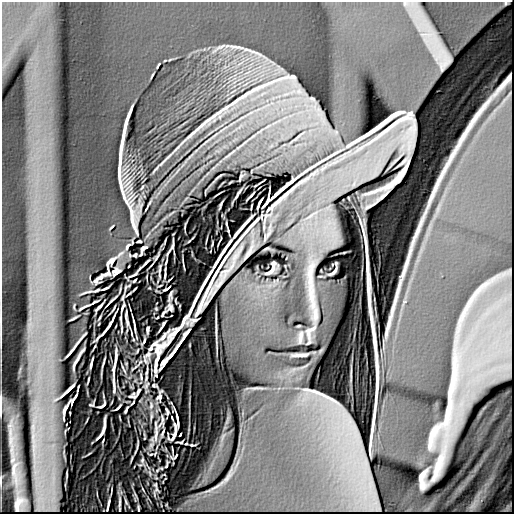

In [ ]:
# Kernel Emboss
kernel_emboss = np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]])
emboss_img = convolution2d(gray_img, kernel_emboss, 1, 2)
cv2_imshow(emboss_img)

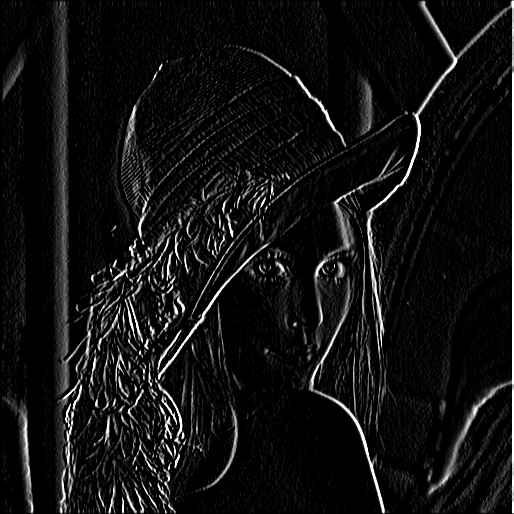

In [ ]:
# Kernel Left Sobel Edge Detection
kernel_lsed = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]])
lsed_img = convolution2d(gray_img, kernel_lsed, 1, 2)
cv2_imshow(lsed_img)

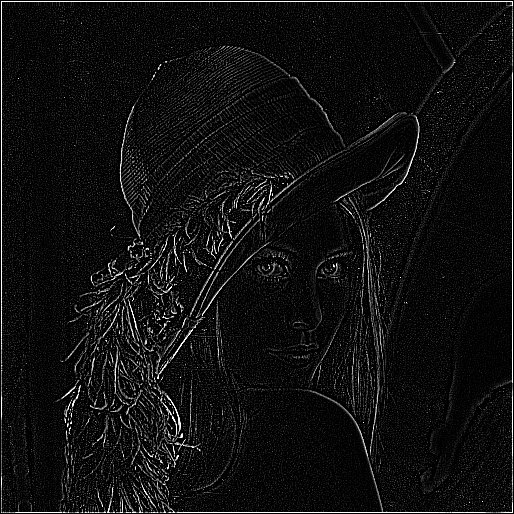

In [ ]:
# Kernel Canny Edge Detection
kernel_ced = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])
ced_img = convolution2d(gray_img, kernel_ced, 1, 2)
cv2_imshow(ced_img)

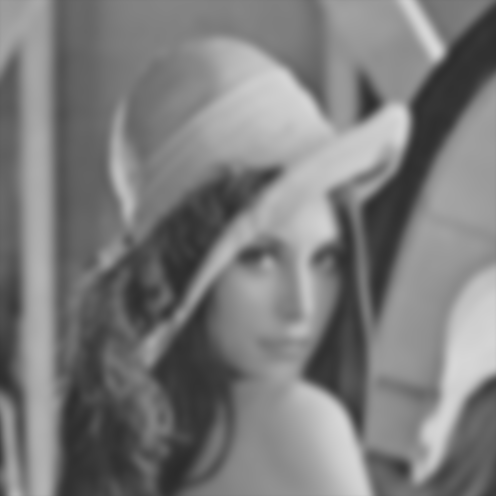

In [ ]:
# Kernel Gaussian Blur (21x21)
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()
gauss_img = convolution2d(gray_img, gauss_kernel, 1, 2)
cv2_imshow(gauss_img)

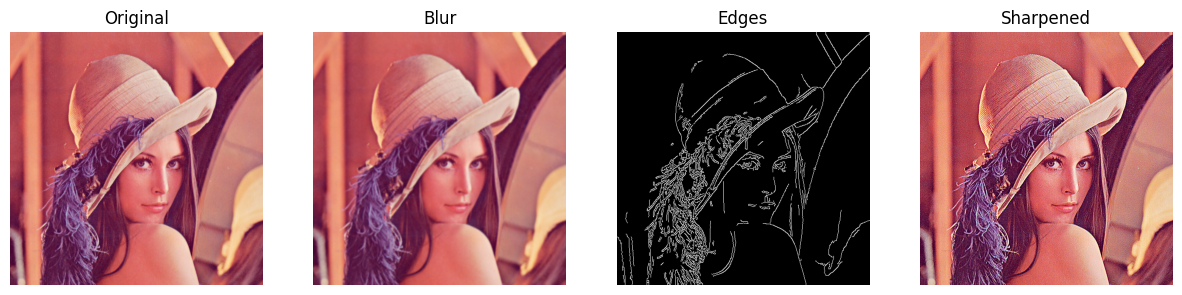

In [ ]:
# Filter menggunakan library filter2d

# Fungsi tampil berdampingan
def  show_side_by_side(images, titles, figsize=(15,5)):
  plt.figure(figsize=figsize)
  for i, (img, title) in enumerate(zip(images, titles)):
    if len(img.shape) == 2:
      plt.subplot(1, len(images), i+1)
      plt.imshow(img, cmap='gray')
    else:
      plt.subplot(1, len(images), i+1)
      plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
  plt.show()

img = cv.imread('/content/drive/MyDrive/PCVK2026/Lenna.png')
gray_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0], [-1,5,-1], [0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, edges, sharpened], ['Original', 'Blur', 'Edges', 'Sharpened'])

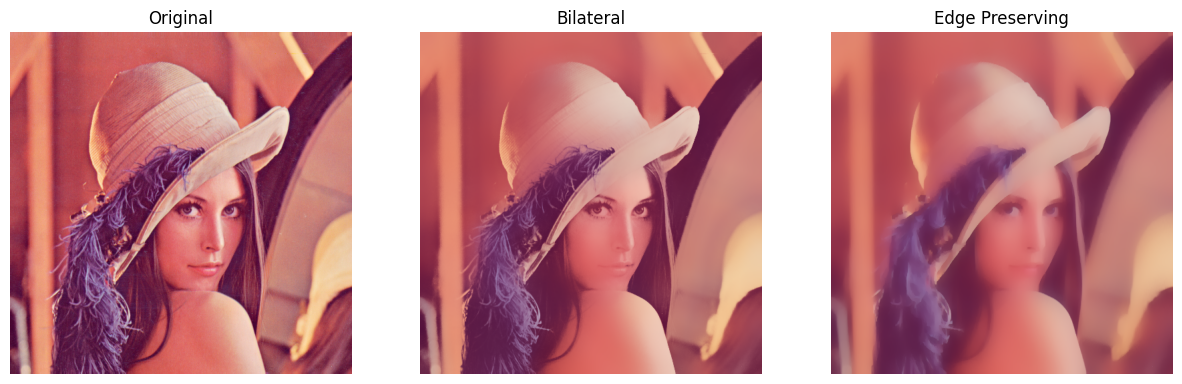

In [ ]:
# Filter modern dari OpenCV

# Bilateral filter
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve], ['Original', 'Bilateral', 'Edge Preserving'])

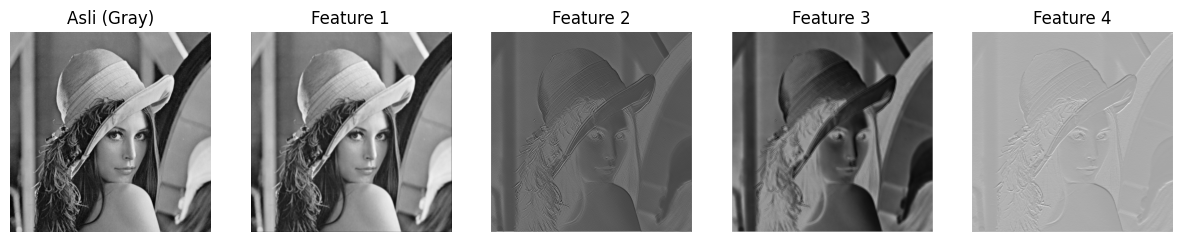

In [ ]:
# Filter Feature Map
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
  def __init__(self):
    super(SimpleCNN, self).__init__()
    self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

  def forward(self, x):
    return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(gray_img, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
  features = model(img_tensor)

# Plot feature map
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
titles = [f'Feature Map {i+1}' for i in range(features.shape[1])]
show_side_by_side([gray_img]+feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

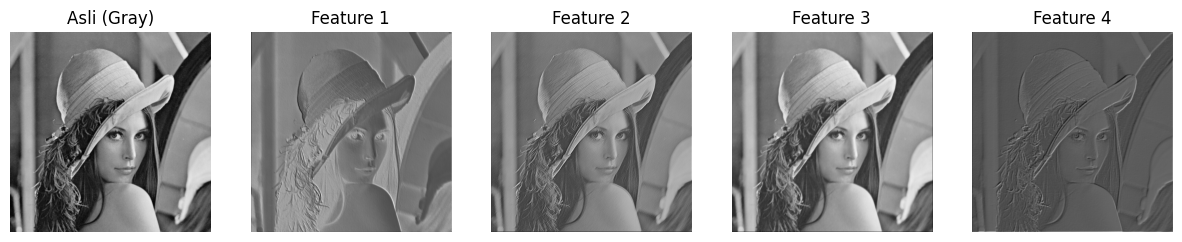

In [ ]:
# Run 2
model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(gray_img, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
  features = model(img_tensor)

# Plot feature map
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
titles = [f'Feature Map {i+1}' for i in range(features.shape[1])]
show_side_by_side([gray_img]+feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

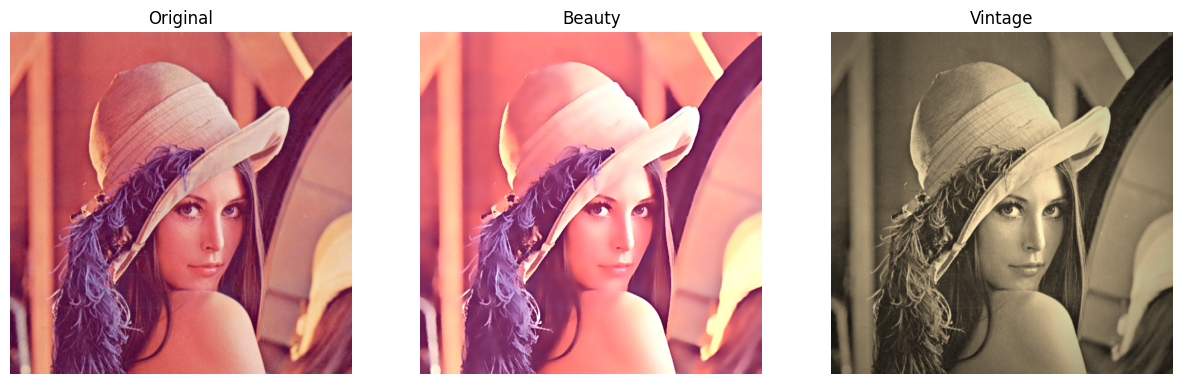

In [ ]:
# Beauty dan Vintage Efek

# Beauty
# Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Brightness dan Contrast
alpha = 1.2
beta = 15
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# Vintage
# Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131], [0.349, 0.686, 0.168], [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
  vignette[:,:,i] = vignette[:,:,i] * mask

# Noise
noise = np.random.normal(0, 15, vignette.shape).astype(np.uint8)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

# Plot
show_side_by_side([img, beauty, vignette], ['Original', 'Beauty', 'Vintage'])

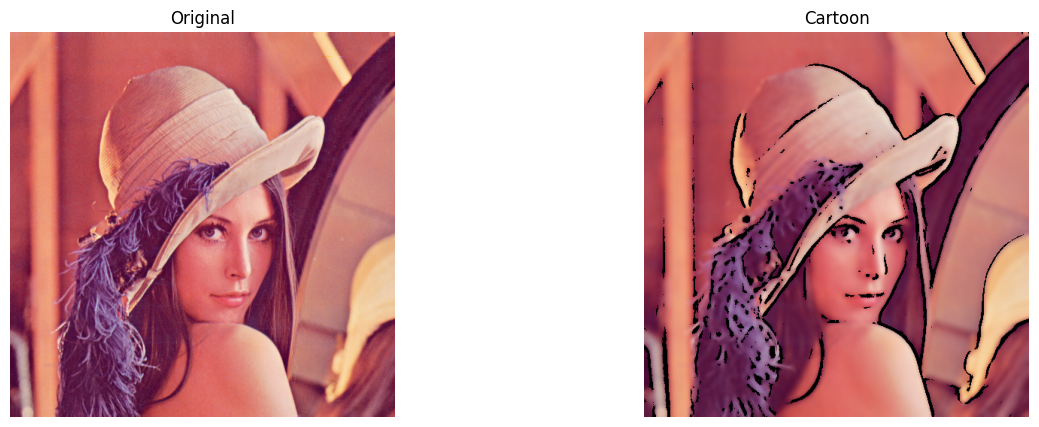

In [52]:
# Cartoon Filter

# Edge detection
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)

# Bilateral filter
color = cv.bilateralFilter(img, 9, 200, 200)

# Cartoon
cartoon = cv.bitwise_and(color, color, mask=edges)

# Plot
show_side_by_side([img, cartoon], ['Original', 'Cartoon'])